In [1]:
import pandas as pd
import seaborn as sns
from sklearn.datasets import make_blobs

In [2]:
# Create dataset
X, y = make_blobs(
    n_samples=1000,
    n_features=2,
    centers=4,
    random_state=42
)

<Axes: >

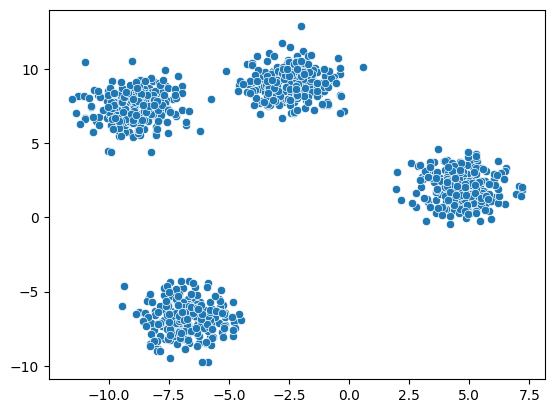

In [3]:
# Visualize
sns.scatterplot(x=X[:,0], y=X[:,1])

In [18]:
# K-Means
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)
labels = kmeans.fit_predict(X)

<Axes: >

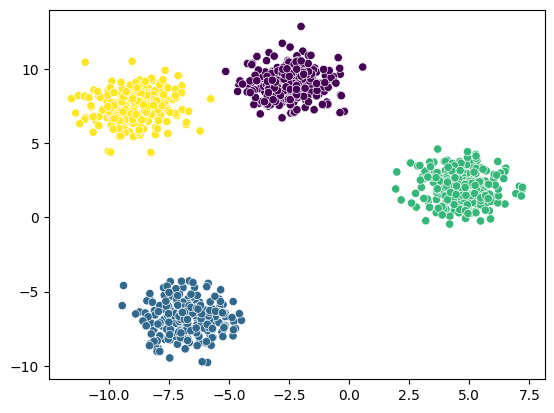

In [19]:
# Visualize
sns.scatterplot(x=X[:,0], y=X[:,1], c=labels)

### K value - elbow & silhouette score

<Axes: >

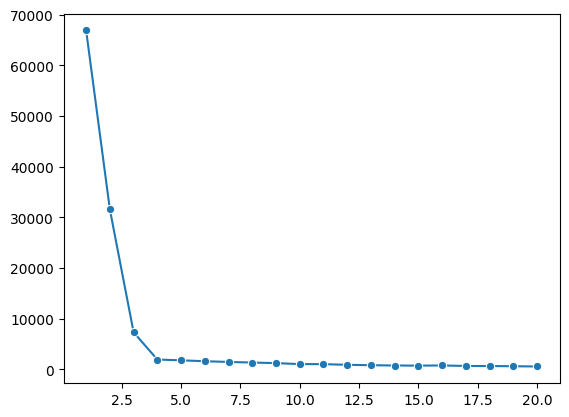

In [25]:
# Elbow method
wcss = []
for k in range(1, 21):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit_predict(X)
    wcss.append(kmeans.inertia_)

sns.lineplot(x=range(1, 21), y=wcss, marker='o')

In [26]:
# Knee Locator
from kneed import KneeLocator

knee = KneeLocator(
    range(1, 21),
    wcss,
    curve="convex",
    direction="decreasing"
)
print("Optimal K Value: ", knee.knee)

Optimal K Value:  4


### Silhouette Score

<Axes: >

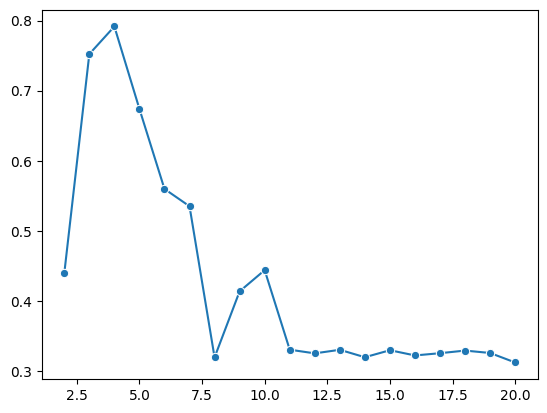

In [29]:
from sklearn.metrics import silhouette_score

ss = []
for k in range(2, 21):
    kmeans = KMeans(n_clusters=k)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    ss.append(score)

sns.lineplot(x=range(2, 21), y=ss, marker='o')